In [1]:
import pandas as pd
import numpy as np
import re

In [2]:
df = pd.read_csv('personalizer_v1_merged.csv.gz_metaevaluation.csv.gz')
df['model_name'] = [x.split('_')[-1].replace('gemma-3-4b-it', 'Gemma-3-4B-it').replace('gemma-3-27b-it', 'Gemma-3-27B-it') for x in df['model_name']]
df['type'] = ['Generation' if x.startswith('Generate') else 'Modification' for x in df['prompt']]

print(df.info())
print(df.majority_personalization_eval.value_counts())
print(df[df.total_agreement_personalization_eval].majority_personalization_eval.value_counts())

train_df = df[df.majority_personalization_eval != -1].reset_index(drop=True)
train_df['label'] = train_df['majority_personalization_eval']
train_df['text'] = train_df['result']
test_df = train_df.groupby(['label']).apply(lambda x: x.sample(min(1000, len(x)), random_state = 0)).sample(frac=1., random_state = 0).reset_index(drop=True)
train_df = train_df[~train_df.text.isin(test_df.text)].sample(frac=1., random_state = 0).reset_index(drop=True)
valid_df = train_df.groupby(['label']).apply(lambda x: x.sample(min(500, len(x)), random_state = 0)).sample(frac=1., random_state = 0).reset_index(drop=True)
train_df = train_df[~train_df.text.isin(valid_df.text)].groupby(['label']).apply(lambda x: x.sample(min(1300, len(x)), random_state = 0)).sample(frac=1., random_state = 0).reset_index(drop=True)
print(train_df.label.value_counts())
print(valid_df.label.value_counts())
print(test_df.label.value_counts())

print(train_df[['label', 'language']].value_counts())
print(valid_df[['label', 'language']].value_counts())
print(test_df[['label', 'language']].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25200 entries, 0 to 25199
Data columns (total 16 columns):
 #   Column                                                    Non-Null Count  Dtype 
---  ------                                                    --------------  ----- 
 0   prompt_id                                                 25200 non-null  int64 
 1   platform_name                                             25200 non-null  object
 2   platform_description                                      25200 non-null  object
 3   language                                                  25200 non-null  object
 4   article_title                                             25200 non-null  object
 5   article_summary                                           25200 non-null  object
 6   template                                                  25200 non-null  object
 7   prompt                                                    25200 non-null  object
 8   model_name                

In [3]:
test_df.type.value_counts()

Generation      2143
Modification    1857
Name: type, dtype: int64

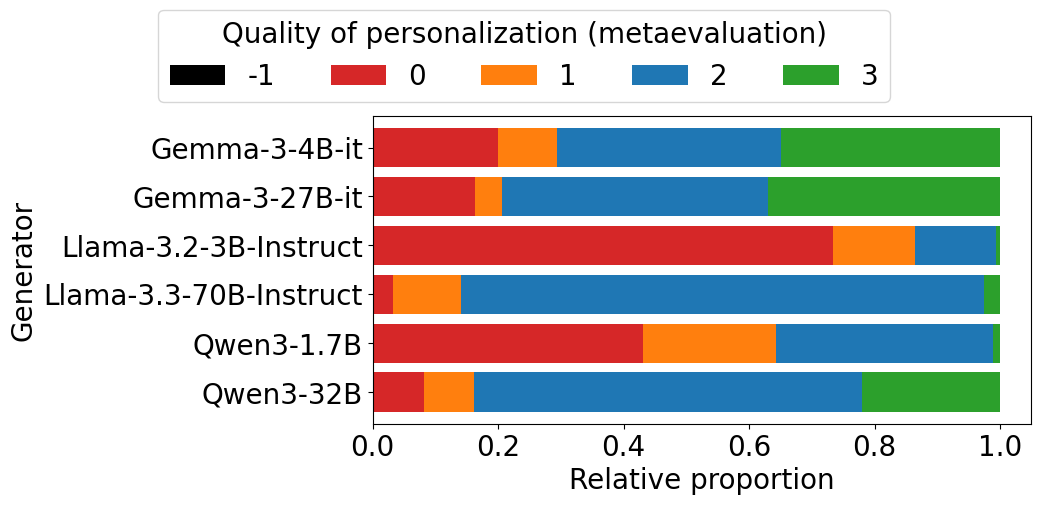

In [76]:
#all data
temp=df.copy()
fontsize=20

temp2 = (temp.groupby(['model_name', 'majority_personalization_eval']).size() / temp.groupby(['model_name']).size()).unstack()
temp2 = temp2.sort_index(key=lambda x: x.map({'Gemma-3-4B-it':0, 'Gemma-3-27B-it':1, 'Llama-3.2-3B-Instruct':2, 'Llama-3.3-70B-Instruct':3, 'Qwen3-1.7B':4, 'Qwen3-32B':5}))

ax = temp2.plot(
    kind='barh',
    stacked=True,
    figsize=(8.5, 4),
    fontsize=fontsize,
    color=["black", '#d62728', '#ff7f0e', '#1f77b4', '#2ca02c'],
    width=0.8,
    #linewidth=0.0,
)


ax.set_xlabel("Relative proportion", fontsize=fontsize)
ax.set_ylabel("Generator", fontsize=fontsize)
ax.invert_yaxis()
ax.legend(title="Quality of personalization (metaevaluation)",ncol=5, loc='lower center',bbox_to_anchor=(0.23, 1), title_fontsize=fontsize, fontsize=fontsize)
ax.figure.savefig("per-generator_metaevaluation_all.pdf", format='pdf', bbox_inches='tight')

In [77]:
temp.model_name.unique()

array(['Gemma-3-27B-it', 'Qwen3-32B', 'Gemma-3-4B-it',
       'Llama-3.2-3B-Instruct', 'Llama-3.3-70B-Instruct', 'Qwen3-1.7B'],
      dtype=object)

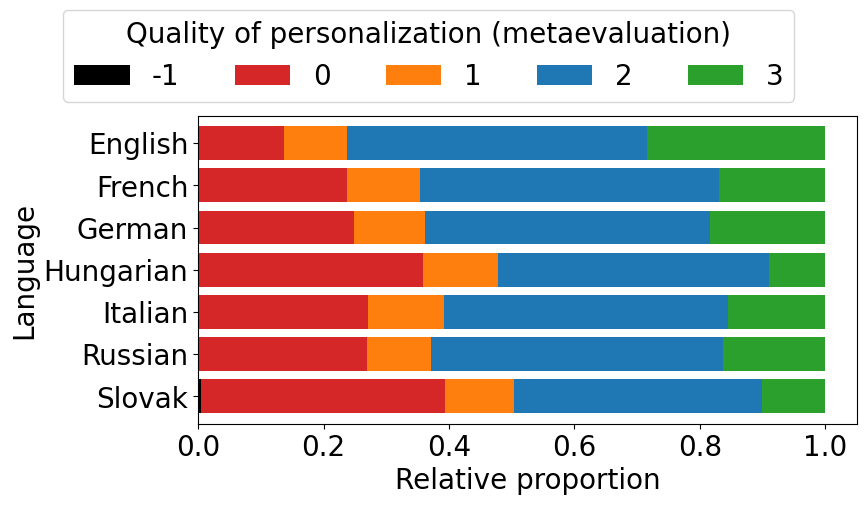

In [78]:
#all data
temp=df.copy()
fontsize=20

ax = (temp.groupby(['language', 'majority_personalization_eval']).size() / temp.groupby(['language']).size()).unstack().plot(
    kind='barh',
    stacked=True,
    figsize=(8.5, 4),
    fontsize=fontsize,
    color=["black", '#d62728', '#ff7f0e', '#1f77b4', '#2ca02c'],
    width=0.8,
    #linewidth=0.0,
)


ax.set_xlabel("Relative proportion", fontsize=fontsize)
ax.set_ylabel("Language", fontsize=fontsize)
ax.invert_yaxis()
ax.legend(title="Quality of personalization (metaevaluation)",ncol=5, loc='lower center',bbox_to_anchor=(0.35, 1), title_fontsize=fontsize, fontsize=fontsize)
ax.figure.savefig("per-language_metaevaluation_all.pdf", format='pdf', bbox_inches='tight')

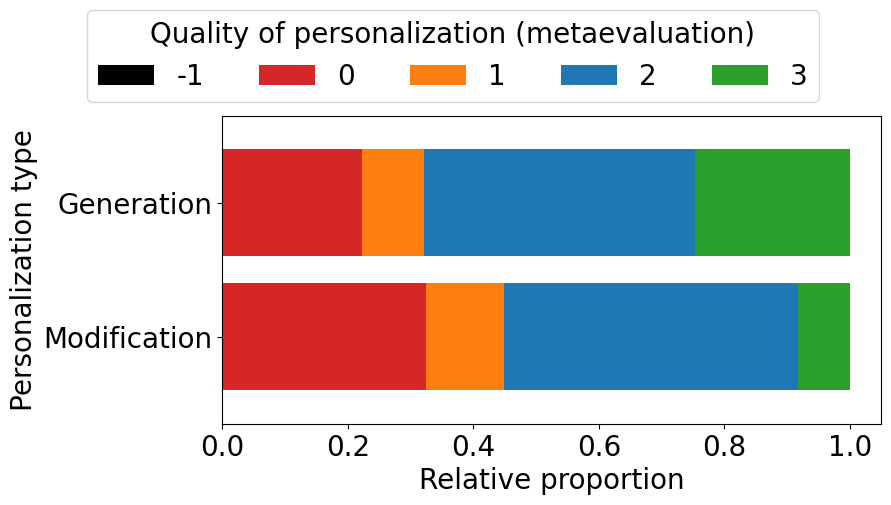

In [79]:
#all data
temp=df.copy()
fontsize=20

ax = (temp.groupby(['type', 'majority_personalization_eval']).size() / temp.groupby(['type']).size()).unstack().plot(
    kind='barh',
    stacked=True,
    figsize=(8.5, 4),
    fontsize=fontsize,
    color=["black", '#d62728', '#ff7f0e', '#1f77b4', '#2ca02c'],
    width=0.8,
    #linewidth=0.0,
)


ax.set_xlabel("Relative proportion", fontsize=fontsize)
ax.set_ylabel("Personalization type", fontsize=fontsize)
ax.invert_yaxis()
ax.legend(title="Quality of personalization (metaevaluation)",ncol=5, loc='lower center',bbox_to_anchor=(0.35, 1), title_fontsize=fontsize, fontsize=fontsize)
ax.figure.savefig("per-type_metaevaluation_all.pdf", format='pdf', bbox_inches='tight')

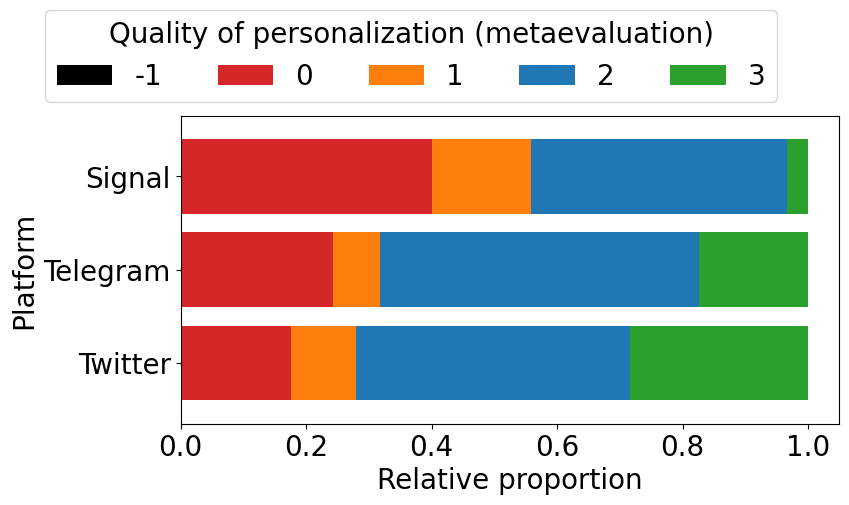

In [4]:
#all data
temp=df.copy()
fontsize=20

ax = (temp.groupby(['platform_name', 'majority_personalization_eval']).size() / temp.groupby(['platform_name']).size()).unstack().plot(
    kind='barh',
    stacked=True,
    figsize=(8.5, 4),
    fontsize=fontsize,
    color=["black", '#d62728', '#ff7f0e', '#1f77b4', '#2ca02c'],
    width=0.8,
    #linewidth=0.0,
)


ax.set_xlabel("Relative proportion", fontsize=fontsize)
ax.set_ylabel("Platform", fontsize=fontsize)
ax.invert_yaxis()
ax.legend(title="Quality of personalization (metaevaluation)",ncol=5, loc='lower center',bbox_to_anchor=(0.35, 1), title_fontsize=fontsize, fontsize=fontsize)
ax.figure.savefig("per-platform_metaevaluation_all.pdf", format='pdf', bbox_inches='tight')

In [5]:
(temp.groupby(['platform_name', 'majority_personalization_eval']).size() / temp.groupby(['platform_name']).size()).unstack()

majority_personalization_eval,-1,0,1,2,3
platform_name,,,,,
Signal,0.000833,0.400119,0.157619,0.407381,0.034048
Telegram,0.000595,0.242381,0.074405,0.508690,0.173929
Twitter,0.000714,0.175833,0.102857,0.436310,0.284286


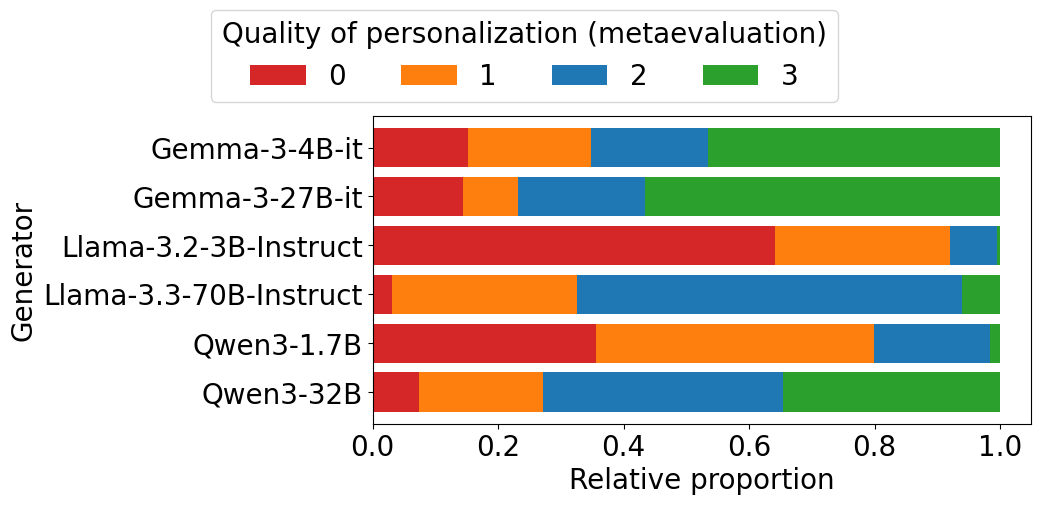

In [81]:
temp=test_df.copy()
fontsize=20

temp2 = (temp.groupby(['model_name', 'majority_personalization_eval']).size() / temp.groupby(['model_name']).size()).unstack()
temp2 = temp2.sort_index(key=lambda x: x.map({'Gemma-3-4B-it':0, 'Gemma-3-27B-it':1, 'Llama-3.2-3B-Instruct':2, 'Llama-3.3-70B-Instruct':3, 'Qwen3-1.7B':4, 'Qwen3-32B':5}))

ax = temp2.plot(
    kind='barh',
    stacked=True,
    figsize=(8.5, 4),
    fontsize=fontsize,
    color=['#d62728', '#ff7f0e', '#1f77b4', '#2ca02c'],
    width=0.8,
    #linewidth=0.0,
)


ax.set_xlabel("Relative proportion", fontsize=fontsize)
ax.set_ylabel("Generator", fontsize=fontsize)
ax.invert_yaxis()
ax.legend(title="Quality of personalization (metaevaluation)",ncol=4, loc='lower center',bbox_to_anchor=(0.23, 1), title_fontsize=fontsize, fontsize=fontsize)
ax.figure.savefig("per-generator_metaevaluation.pdf", format='pdf', bbox_inches='tight')

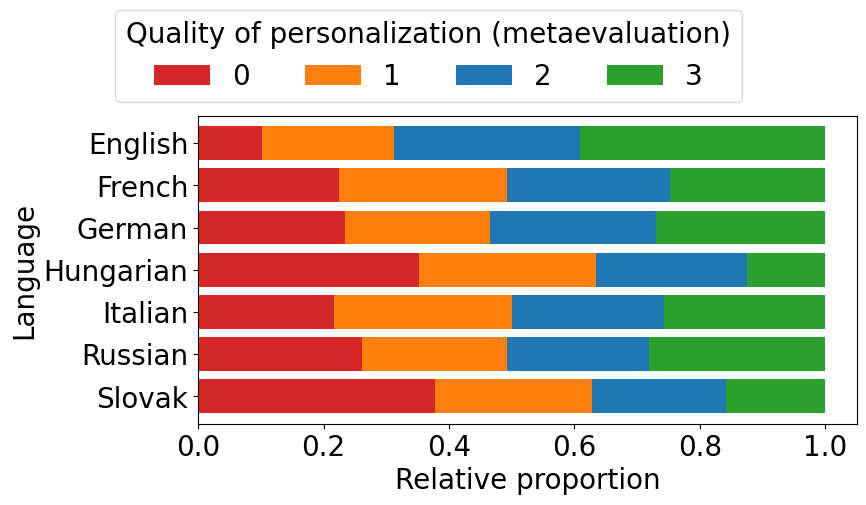

In [82]:
temp=test_df.copy()
fontsize=20

ax = (temp.groupby(['language', 'majority_personalization_eval']).size() / temp.groupby(['language']).size()).unstack().plot(
    kind='barh',
    stacked=True,
    figsize=(8.5, 4),
    fontsize=fontsize,
    color=['#d62728', '#ff7f0e', '#1f77b4', '#2ca02c'],
    width=0.8,
    #linewidth=0.0,
)


ax.set_xlabel("Relative proportion", fontsize=fontsize)
ax.set_ylabel("Language", fontsize=fontsize)
ax.invert_yaxis()
ax.legend(title="Quality of personalization (metaevaluation)",ncol=4, loc='lower center',bbox_to_anchor=(0.35, 1), title_fontsize=fontsize, fontsize=fontsize)
ax.figure.savefig("per-language_metaevaluation.pdf", format='pdf', bbox_inches='tight')

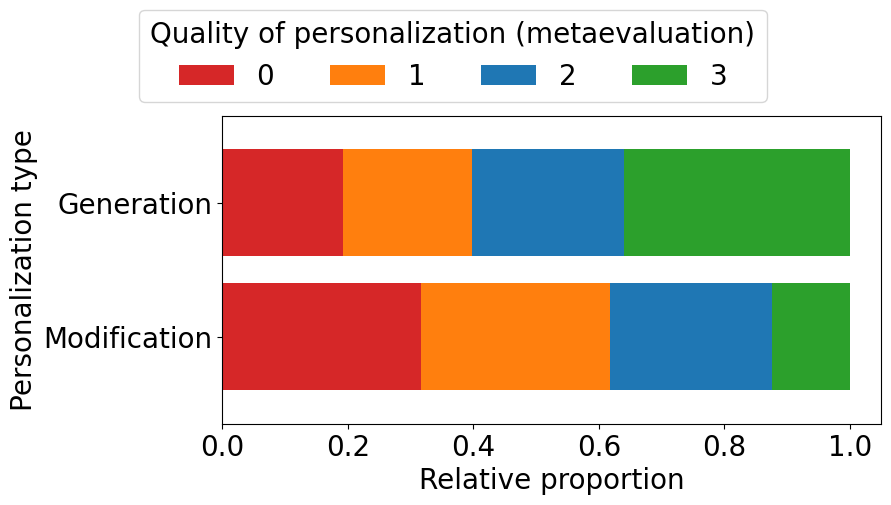

In [83]:
temp=test_df.copy()
fontsize=20

ax = (temp.groupby(['type', 'majority_personalization_eval']).size() / temp.groupby(['type']).size()).unstack().plot(
    kind='barh',
    stacked=True,
    figsize=(8.5, 4),
    fontsize=fontsize,
    color=['#d62728', '#ff7f0e', '#1f77b4', '#2ca02c'],
    width=0.8,
    #linewidth=0.0,
)


ax.set_xlabel("Relative proportion", fontsize=fontsize)
ax.set_ylabel("Personalization type", fontsize=fontsize)
ax.invert_yaxis()
ax.legend(title="Quality of personalization (metaevaluation)",ncol=4, loc='lower center',bbox_to_anchor=(0.35, 1), title_fontsize=fontsize, fontsize=fontsize)
ax.figure.savefig("per-type_metaevaluation.pdf", format='pdf', bbox_inches='tight')

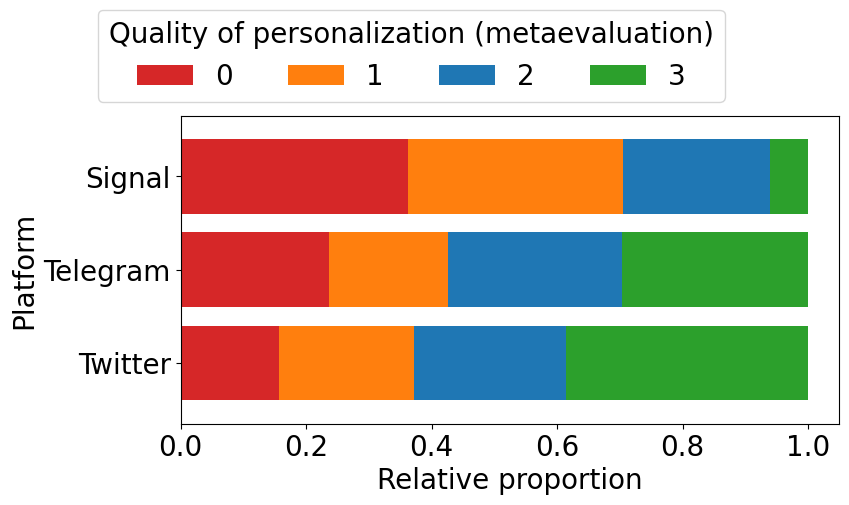

In [6]:
temp=test_df.copy()
fontsize=20

ax = (temp.groupby(['platform_name', 'majority_personalization_eval']).size() / temp.groupby(['platform_name']).size()).unstack().plot(
    kind='barh',
    stacked=True,
    figsize=(8.5, 4),
    fontsize=fontsize,
    color=['#d62728', '#ff7f0e', '#1f77b4', '#2ca02c'],
    width=0.8,
    #linewidth=0.0,
)


ax.set_xlabel("Relative proportion", fontsize=fontsize)
ax.set_ylabel("Platform", fontsize=fontsize)
ax.invert_yaxis()
ax.legend(title="Quality of personalization (metaevaluation)",ncol=4, loc='lower center',bbox_to_anchor=(0.35, 1), title_fontsize=fontsize, fontsize=fontsize)
ax.figure.savefig("per-platform_metaevaluation.pdf", format='pdf', bbox_inches='tight')

In [7]:
(temp.groupby(['platform_name', 'majority_personalization_eval']).size() / temp.groupby(['platform_name']).size()).unstack()

majority_personalization_eval,0,1,2,3
platform_name,,,,
Signal,0.362957,0.342793,0.233757,0.060493
Telegram,0.236667,0.189167,0.278333,0.295833
Twitter,0.157426,0.214921,0.241615,0.386037


In [2]:
df = pd.read_csv('personalizer_v1_merged.csv.gz_metaevaluation_test_prediction.csv.gz')
df['model_name'] = [x.split('_')[-1].replace('gemma-3-4b-it', 'Gemma-3-4B-it').replace('gemma-3-27b-it', 'Gemma-3-27B-it') for x in df['model_name']]
df['type'] = ['Generation' if x.startswith('Generate') else 'Modification' for x in df['prompt']]

In [7]:
df.corr(method="spearman").loc["majority_personalization_eval",:]

prompt_id                                                  -0.291230
Mistral-Small-3.1-24B-Instruct-2503_personalization_eval    0.932426
aya-expanse-32b_personalization_eval                        0.747767
QwQ-32B_personalization_eval                                0.871546
majority_personalization_eval                               1.000000
total_agreement_personalization_eval                        0.087287
label                                                       1.000000
Qwen3-4B-Base_prediction                                    0.849650
mdeberta-v3-base_prediction                                 0.826595
gemma-2-2b_prediction                                       0.846775
xlm-roberta-large_prediction                                0.828827
xlm-roberta-base_prediction                                 0.816733
deberta-v3-large_prediction                                 0.852639
Qwen3-0.6B-Base_prediction                                  0.840665
Qwen3-1.7B-Base_prediction        

In [3]:
df

,prompt_id,platform_name,platform_description,language,article_title,article_summary,template,prompt,model_name,result,...,text,Qwen3-4B-Base_prediction,mdeberta-v3-base_prediction,gemma-2-2b_prediction,xlm-roberta-large_prediction,xlm-roberta-base_prediction,deberta-v3-large_prediction,Qwen3-0.6B-Base_prediction,Qwen3-1.7B-Base_prediction,type
0,454,Twitter,"Twitter is a fast-paced, public social network...",French,Poutine lève des sanctions contre la Turquie,Le président russe Vladimir Poutine a signé au...,Personalize the following news article for the...,Personalize the following news article for the...,Qwen3-32B,Moscou réduit les tensions avec Ankara : Pouti...,...,Moscou réduit les tensions avec Ankara : Pouti...,2,2,2,3,2,2,2,2,Modification
1,3628,Signal,Signal is a private messaging app that allows ...,German,Daviscup-Kapitän: Stich ist willig und billig,Nach sechs Jahren kehren Sie zum Daviscup zurü...,Personalize the following news article for the...,Personalize the following news article for the...,Gemma-3-4B-it,"**Signal-Nachricht:**\n\nHey Leute, mal was Co...",...,"**Signal-Nachricht:**\n\nHey Leute, mal was Co...",0,0,1,1,1,0,0,1,Modification
2,642,Twitter,"Twitter is a fast-paced, public social network...",English,Russian Police Raids Target Japanese Doomsday ...,MOSCOW - Russian police detained a number of a...,Personalize the following news article for the...,Personalize the following news article for the...,Gemma-3-4B-it,🚨 HUGE NEWS! 🇷🇺💥 Russian police just raided ov...,...,🚨 HUGE NEWS! 🇷🇺💥 Russian police just raided ov...,3,3,3,3,3,3,3,3,Modification
3,3995,Signal,Signal is a private messaging app that allows ...,Russian,"Чистая прибыль ""Северстали"" выросла до $1,94 млрд",-,"Generate a news article for the ""%platform_nam...","Generate a news article for the ""Signal"" platf...",Qwen3-32B,Привет! Хотела поделиться важной новостью: пос...,...,Привет! Хотела поделиться важной новостью: пос...,2,2,3,2,2,2,2,2,Generation
4,1878,Telegram,Telegram is a cloud-based messaging platform t...,French,Pourquoi le Stade Rennais va marcher sur Arsenal,Après son exploit sur la pelouse du Betis il y...,Personalize the following news article for the...,Personalize the following news article for the...,Gemma-3-4B-it,🚨 24494956566579884101101011012373726102102898...,...,🚨 24494956566579884101101011012373726102102898...,0,0,0,0,0,0,0,0,Modification
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,610,Twitter,"Twitter is a fast-paced, public social network...",Slovak,Aj policajní úradníci pôjdu do služby,22. mar 2001 o 0:00\n\nČASTÁ-PAPIERNIČKA – Od ...,Personalize the following news article for the...,Personalize the following news article for the...,Llama-3.2-3B-Instruct,Štedrne Informacie ze SNP ## Aj policajní úrad...,...,Štedrne Informacie ze SNP ## Aj policajní úrad...,0,0,0,0,0,0,0,0,Modification
3996,1955,Telegram,Telegram is a cloud-based messaging platform t...,French,L'AS Roma ouvre un compte Twitter en pidgin,-,"Generate a news article for the ""%platform_nam...","Generate a news article for the ""Telegram"" pla...",Gemma-3-4B-it,"Okay, here’s a Telegram post adapting the prov...",...,"Okay, here’s a Telegram post adapting the prov...",3,3,3,3,3,3,3,3,Generation
3997,1289,Twitter,"Twitter is a fast-paced, public social network...",French,"Au Brésil, une épidémie historique de dengue m...",-,"Generate a news article for the ""%platform_nam...","Generate a news article for the ""Twitter"" plat...",Llama-3.2-3B-Instruct,"""Dengue se déverse au Brésil : Après deux mill...",...,"""Dengue se déverse au Brésil : Après deux mill...",1,1,1,2,2,1,1,1,Generation
3998,3475,Signal,Signal is a private messaging app that allows ...,Slovak,Otázka života a smrti - si moslim či kresťan?,-,"Generate a news article for the ""%platform_nam...","Generate a news article for the ""Signal"" platf...",Gemma-3-4B-it,**Návrh pre Signal:**\n\n**(Obrázok: Zjemnená ...,...,**Návrh pre Signal:**\n\n**(O

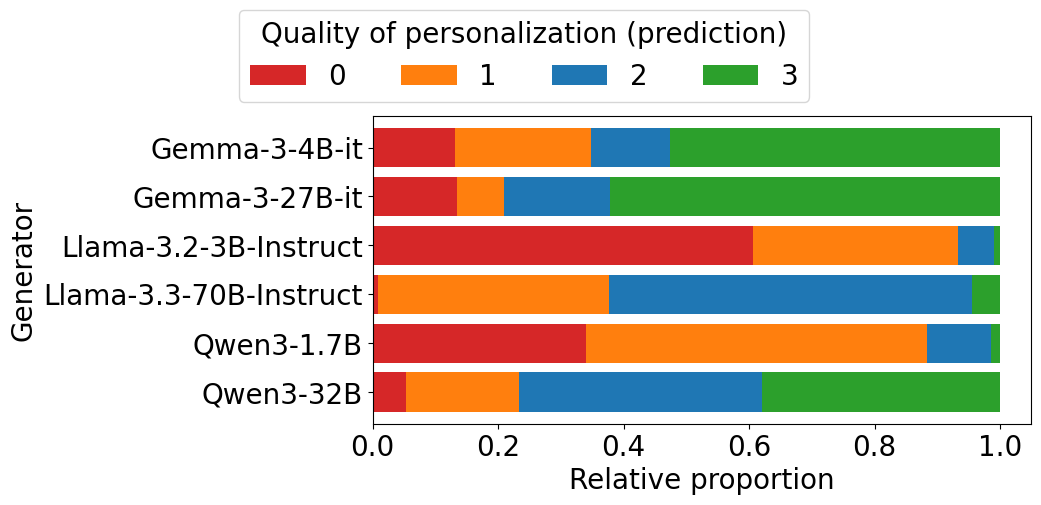

In [8]:
temp=df.copy()
fontsize=20

column='gemma-2-2b_prediction'
temp2 = (temp.groupby(['model_name', column]).size() / temp.groupby(['model_name']).size()).unstack()
temp2 = temp2.sort_index(key=lambda x: x.map({'Gemma-3-4B-it':0, 'Gemma-3-27B-it':1, 'Llama-3.2-3B-Instruct':2, 'Llama-3.3-70B-Instruct':3, 'Qwen3-1.7B':4, 'Qwen3-32B':5}))

ax = temp2.plot(
    kind='barh',
    stacked=True,
    figsize=(8.5, 4),
    fontsize=fontsize,
    color=['#d62728', '#ff7f0e', '#1f77b4', '#2ca02c'],
    width=0.8,
    #linewidth=0.0,
)


ax.set_xlabel("Relative proportion", fontsize=fontsize)
ax.set_ylabel("Generator", fontsize=fontsize)
ax.invert_yaxis()
ax.legend(title="Quality of personalization (prediction)",ncol=4, loc='lower center',bbox_to_anchor=(0.23, 1), title_fontsize=fontsize, fontsize=fontsize)
ax.figure.savefig(f"per-generator_{column}.pdf", format='pdf', bbox_inches='tight')

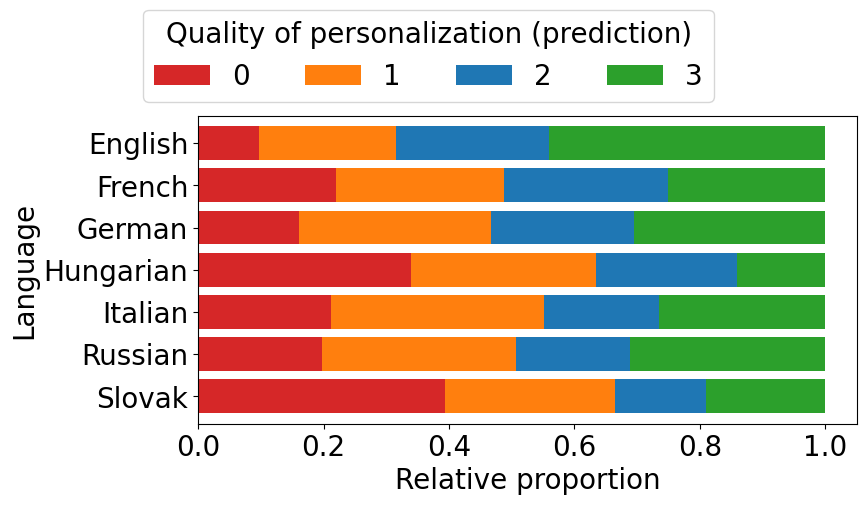

In [9]:
temp=df.copy()
fontsize=20

column='gemma-2-2b_prediction'
ax = (temp.groupby(['language', column]).size() / temp.groupby(['language']).size()).unstack().plot(
    kind='barh',
    stacked=True,
    figsize=(8.5, 4),
    fontsize=fontsize,
    color=['#d62728', '#ff7f0e', '#1f77b4', '#2ca02c'],
    width=0.8,
    #linewidth=0.0,
)


ax.set_xlabel("Relative proportion", fontsize=fontsize)
ax.set_ylabel("Language", fontsize=fontsize)
ax.invert_yaxis()
ax.legend(title="Quality of personalization (prediction)",ncol=4, loc='lower center',bbox_to_anchor=(0.35, 1), title_fontsize=fontsize, fontsize=fontsize)
ax.figure.savefig(f"per-language_{column}.pdf", format='pdf', bbox_inches='tight')

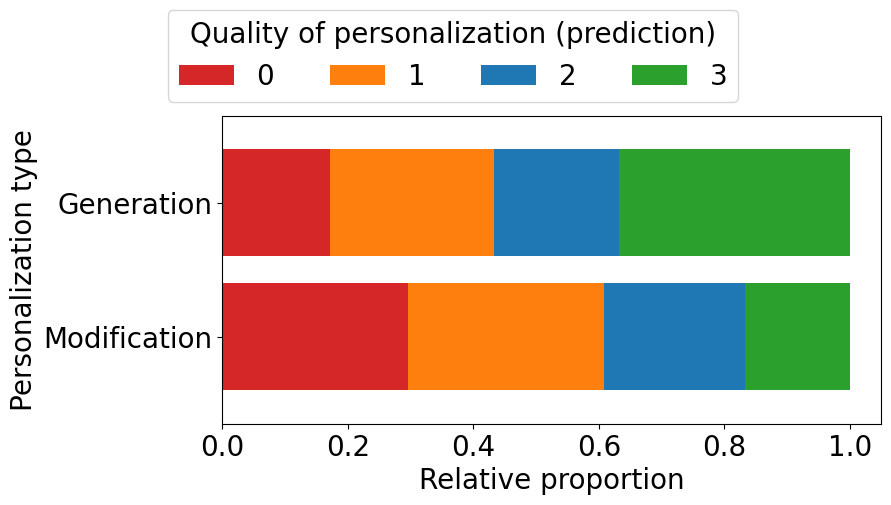

In [10]:
temp=df.copy()
fontsize=20

column='gemma-2-2b_prediction'
ax = (temp.groupby(['type', column]).size() / temp.groupby(['type']).size()).unstack().plot(
    kind='barh',
    stacked=True,
    figsize=(8.5, 4),
    fontsize=fontsize,
    color=['#d62728', '#ff7f0e', '#1f77b4', '#2ca02c'],
    width=0.8,
    #linewidth=0.0,
)


ax.set_xlabel("Relative proportion", fontsize=fontsize)
ax.set_ylabel("Personalization type", fontsize=fontsize)
ax.invert_yaxis()
ax.legend(title="Quality of personalization (prediction)",ncol=4, loc='lower center',bbox_to_anchor=(0.35, 1), title_fontsize=fontsize, fontsize=fontsize)
ax.figure.savefig(f"per-type_{column}.pdf", format='pdf', bbox_inches='tight')

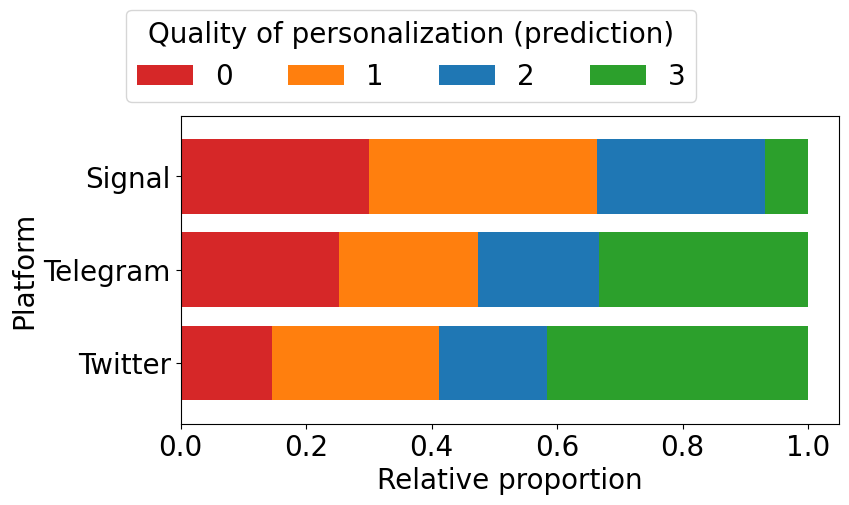

In [11]:
temp=df.copy()
fontsize=20

column='gemma-2-2b_prediction'
ax = (temp.groupby(['platform_name', column]).size() / temp.groupby(['platform_name']).size()).unstack().plot(
    kind='barh',
    stacked=True,
    figsize=(8.5, 4),
    fontsize=fontsize,
    color=['#d62728', '#ff7f0e', '#1f77b4', '#2ca02c'],
    width=0.8,
    #linewidth=0.0,
)


ax.set_xlabel("Relative proportion", fontsize=fontsize)
ax.set_ylabel("Platform", fontsize=fontsize)
ax.invert_yaxis()
ax.legend(title="Quality of personalization (prediction)",ncol=4, loc='lower center',bbox_to_anchor=(0.35, 1), title_fontsize=fontsize, fontsize=fontsize)
ax.figure.savefig(f"per-platform_{column}.pdf", format='pdf', bbox_inches='tight')

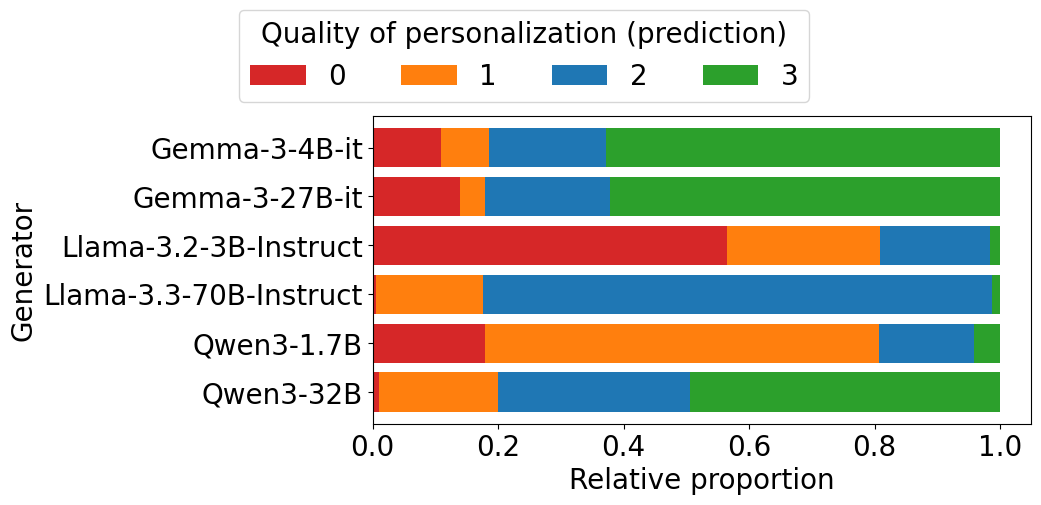

In [12]:
temp=df.copy()
fontsize=20

column='xlm-roberta-base_prediction'
temp2 = (temp.groupby(['model_name', column]).size() / temp.groupby(['model_name']).size()).unstack()
temp2 = temp2.sort_index(key=lambda x: x.map({'Gemma-3-4B-it':0, 'Gemma-3-27B-it':1, 'Llama-3.2-3B-Instruct':2, 'Llama-3.3-70B-Instruct':3, 'Qwen3-1.7B':4, 'Qwen3-32B':5}))

ax = temp2.plot(
    kind='barh',
    stacked=True,
    figsize=(8.5, 4),
    fontsize=fontsize,
    color=['#d62728', '#ff7f0e', '#1f77b4', '#2ca02c'],
    width=0.8,
    #linewidth=0.0,
)


ax.set_xlabel("Relative proportion", fontsize=fontsize)
ax.set_ylabel("Generator", fontsize=fontsize)
ax.invert_yaxis()
ax.legend(title="Quality of personalization (prediction)",ncol=4, loc='lower center',bbox_to_anchor=(0.23, 1), title_fontsize=fontsize, fontsize=fontsize)
ax.figure.savefig(f"per-generator_{column}.pdf", format='pdf', bbox_inches='tight')

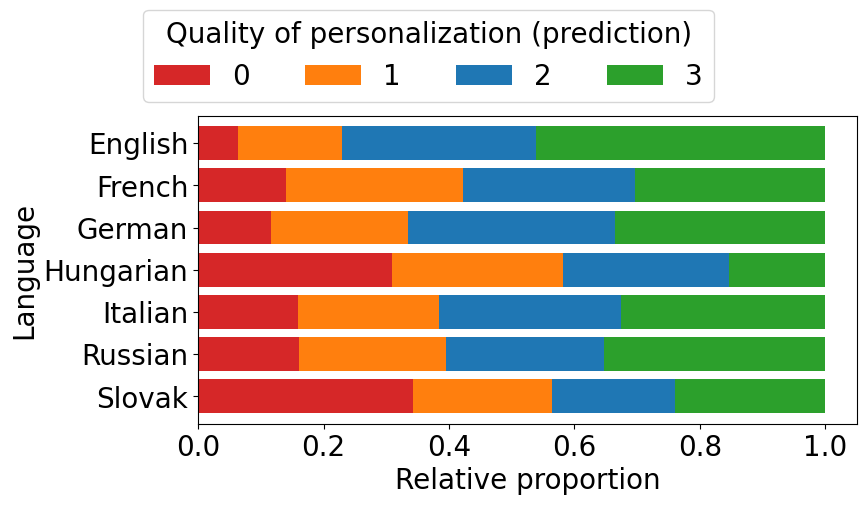

In [13]:
temp=df.copy()
fontsize=20

column='xlm-roberta-base_prediction'
ax = (temp.groupby(['language', column]).size() / temp.groupby(['language']).size()).unstack().plot(
    kind='barh',
    stacked=True,
    figsize=(8.5, 4),
    fontsize=fontsize,
    color=['#d62728', '#ff7f0e', '#1f77b4', '#2ca02c'],
    width=0.8,
    #linewidth=0.0,
)


ax.set_xlabel("Relative proportion", fontsize=fontsize)
ax.set_ylabel("Language", fontsize=fontsize)
ax.invert_yaxis()
ax.legend(title="Quality of personalization (prediction)",ncol=4, loc='lower center',bbox_to_anchor=(0.35, 1), title_fontsize=fontsize, fontsize=fontsize)
ax.figure.savefig(f"per-language_{column}.pdf", format='pdf', bbox_inches='tight')

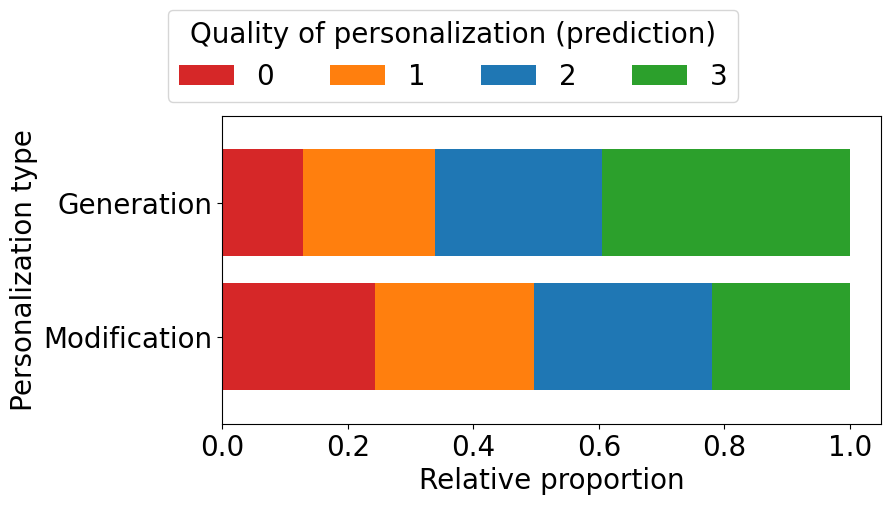

In [14]:
temp=df.copy()
fontsize=20

column='xlm-roberta-base_prediction'
ax = (temp.groupby(['type', column]).size() / temp.groupby(['type']).size()).unstack().plot(
    kind='barh',
    stacked=True,
    figsize=(8.5, 4),
    fontsize=fontsize,
    color=['#d62728', '#ff7f0e', '#1f77b4', '#2ca02c'],
    width=0.8,
    #linewidth=0.0,
)


ax.set_xlabel("Relative proportion", fontsize=fontsize)
ax.set_ylabel("Personalization type", fontsize=fontsize)
ax.invert_yaxis()
ax.legend(title="Quality of personalization (prediction)",ncol=4, loc='lower center',bbox_to_anchor=(0.35, 1), title_fontsize=fontsize, fontsize=fontsize)
ax.figure.savefig(f"per-type_{column}.pdf", format='pdf', bbox_inches='tight')

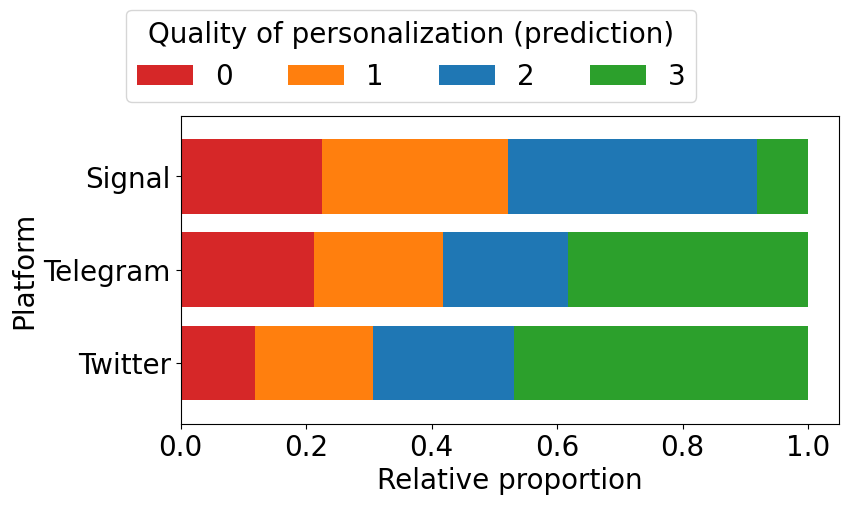

In [15]:
temp=df.copy()
fontsize=20

column='xlm-roberta-base_prediction'
ax = (temp.groupby(['platform_name', column]).size() / temp.groupby(['platform_name']).size()).unstack().plot(
    kind='barh',
    stacked=True,
    figsize=(8.5, 4),
    fontsize=fontsize,
    color=['#d62728', '#ff7f0e', '#1f77b4', '#2ca02c'],
    width=0.8,
    #linewidth=0.0,
)


ax.set_xlabel("Relative proportion", fontsize=fontsize)
ax.set_ylabel("Platform", fontsize=fontsize)
ax.invert_yaxis()
ax.legend(title="Quality of personalization (prediction)",ncol=4, loc='lower center',bbox_to_anchor=(0.35, 1), title_fontsize=fontsize, fontsize=fontsize)
ax.figure.savefig(f"per-platform_{column}.pdf", format='pdf', bbox_inches='tight')